In [2]:
import numpy as np
from numpy.fft import fft, fftfreq
import matplotlib.pyplot as plt

In [3]:
data_path = r'/home/cameron/Desktop/research/rfsoc_analysis/big_buffer_5pairs.npy'
data = np.load(r'/home/cameron/Desktop/research/rfsoc_analysis/big_buffer_5pairs.npy')
# data += int((2**14)/2)

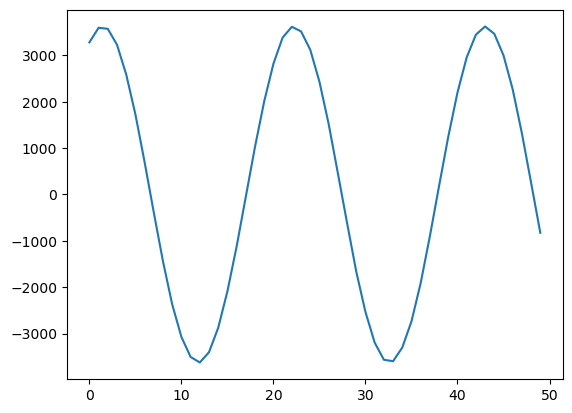

In [4]:
fig, ax = plt.subplots()
ax.plot(data[0,0,:50])
plt.show()

In [5]:
NUM_SAMP = data.shape[2]
NUM_PAIRS = data.shape[0]
DECIMATION = 16
SAMP_FREQ = 4e9/DECIMATION

In [6]:
iq_data = np.zeros((2, NUM_PAIRS, NUM_SAMP), dtype=np.complex128)
iq_data[0] = data[:,0,:] + 1j*data[:,1,:]
iq_data[1] = data[:,2,:] + 1j*data[:,3,:]

In [7]:
FREQ_DOMAIN = fftfreq(NUM_SAMP, 1/SAMP_FREQ)
iq_data_freq = fft(iq_data, axis=2)

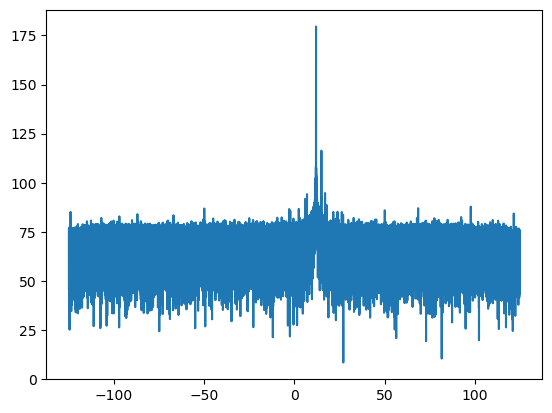

In [8]:
fig, ax = plt.subplots()
ax.plot(FREQ_DOMAIN*1e-6, 20*np.log10(np.abs(iq_data_freq[0, 0])))
# ax.plot(FREQ_DOMAIN*1e-6, 20*np.log10(np.abs(iq_data_freq[1, 0])))
plt.show()


In [9]:
carrier_indices = np.argmax(np.abs(iq_data_freq), axis=2)
print(carrier_indices)
print(carrier_indices.shape)
carrier_freqs = FREQ_DOMAIN[carrier_indices]
print(carrier_freqs.shape)
print(carrier_freqs)
row_inds = np.arange(2)[:,None]
col_inds = np.arange(NUM_PAIRS)
carrier_phases = np.abs(np.angle(iq_data_freq[row_inds, col_inds, carrier_indices]))
print(carrier_phases)
print(carrier_phases.shape)
iq_data_new = iq_data * np.exp(-1j * (2*np.pi*carrier_freqs[:,:,np.newaxis]/SAMP_FREQ*np.arange(NUM_SAMP) + carrier_phases[:,:,np.newaxis]))
print(iq_data_new.shape)
avg_phases = np.average(np.angle(iq_data_new), axis=2)
print(avg_phases.shape)
iq_data_new2 = np.exp(-1j*avg_phases[:,:,np.newaxis])*iq_data_new
print(iq_data_new2.shape)
# print(iq_data_new2)

[[12604 12604 12604 12604 12604]
 [12604 12604 12604 12604 12604]]
(2, 5)
(2, 5)
[[12020111.08398437 12020111.08398437 12020111.08398437 12020111.08398437
  12020111.08398437]
 [12020111.08398437 12020111.08398437 12020111.08398437 12020111.08398437
  12020111.08398437]]
[[0.39952635 0.87284647 1.84468334 0.79161564 1.1222089 ]
 [0.36195595 0.83536165 1.88216188 0.75406772 1.08469988]]
(2, 5)
(2, 5, 262144)
(2, 5)
(2, 5, 262144)


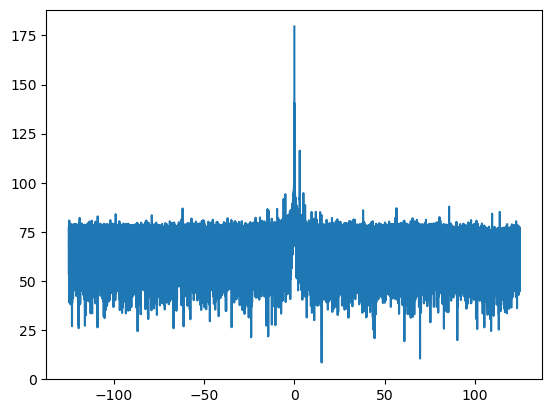

[[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]


In [10]:
iq_data_new_freq = fft(iq_data_new, axis=2)

fig, ax = plt.subplots()
ax.plot(FREQ_DOMAIN*1e-6, 20*np.log10(np.abs(iq_data_new_freq[0, 0])))
# ax.plot(FREQ_DOMAIN*1e-6, 20*np.log10(np.abs(iq_data_new_freq[1, 0])))
plt.show()

print(FREQ_DOMAIN[np.argmax(np.abs(iq_data_new_freq), axis=2)])

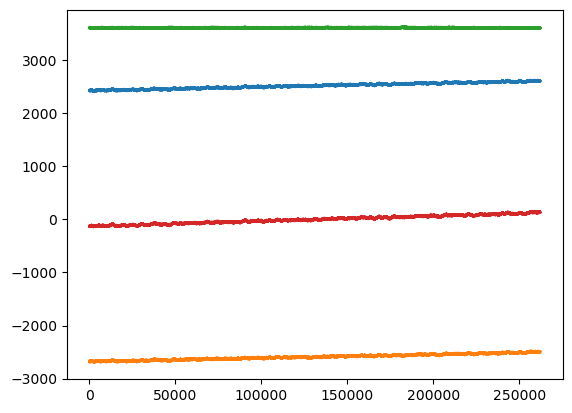

In [11]:
fig, ax = plt.subplots()
ax.plot(np.real(iq_data_new[0,0]))
ax.plot(np.imag(iq_data_new[0,0]))
ax.plot(np.real(iq_data_new2[0,0]))
ax.plot(np.imag(iq_data_new2[0,0]))
plt.show()

In [12]:
TIME_DOMAIN = np.arange(NUM_SAMP)/SAMP_FREQ
FLIP_FREQ = 1.92e3
MASK_L = (TIME_DOMAIN >= 0) & (TIME_DOMAIN < 1/FLIP_FREQ)
MASK_R = (TIME_DOMAIN >= 1/FLIP_FREQ) & (TIME_DOMAIN < 2/FLIP_FREQ)

In [13]:
l_data = np.real(iq_data_new2[:,:,MASK_L])
r_data = np.real(iq_data_new2[:,:,MASK_R])
l_data_avg = np.average(l_data, axis=2)
r_data_avg = np.average(r_data, axis=2)
print(l_data.shape)
print(r_data.shape)
print(l_data_avg.shape)
print(r_data_avg.shape)
rdfs = (r_data_avg - l_data_avg) / (r_data_avg + l_data_avg)
print(rdfs.shape)
ddfs = 1/np.sqrt(2) * (rdfs[0] - rdfs[1])
print(ddfs.shape)
print(ddfs)

(2, 5, 130209)
(2, 5, 130208)
(2, 5)
(2, 5)
(2, 5)
(5,)
[ 4.15344803e-06  1.14350676e-06 -8.92317779e-06 -2.60137652e-06
  4.42312477e-06]
